In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from copy import deepcopy
import jax

# Euclid software
from cloelite.cosmology.jax_cosmology import JAXBackground
from cloelite.cosmology.jax_cosmology import JAXLinearPerturbations
from cloelite.cosmology.jax_cosmology import JAXNonLinearPerturbations
from cloelite.observables.two_point import AngularTwoPoint
from cloelite.observables import photo
import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=20)

In [2]:
# Read the dndz
z_pos, dndz_pos = el.photo.redshift_distributions('data/nz.pos.fits')
z_she, dndz_she = el.photo.redshift_distributions('data/nz.wl.fits')

In [3]:
z_pos - np.linspace(0,6,3001)

array([0., 0., 0., ..., 0., 0., 0.])

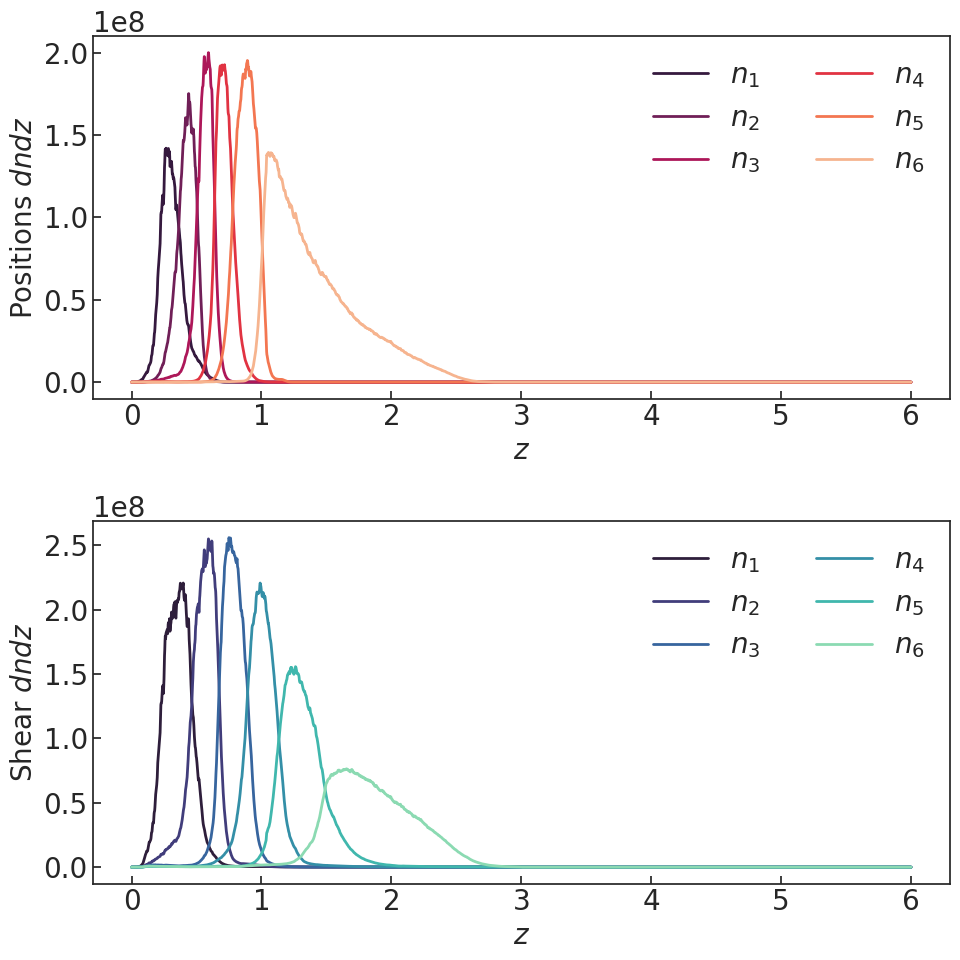

In [4]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $dndz$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $dndz$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

In [5]:
# Normalise dndz
dndz_pos_norm = deepcopy(dndz_pos)
for key in dndz_pos.keys():
    dndz_pos_norm[key] = dndz_pos[key] / integrate.trapezoid(
                        dndz_pos[key], z_pos)

dndz_she_norm = deepcopy(dndz_she)
for key in dndz_she.keys():
    dndz_she_norm[key] = dndz_she[key] / integrate.trapezoid(
                        dndz_she[key], z_she)

my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
myz = np.linspace(1e-3, 3., 300)
my_dndz_pos_norm = np.zeros([6, 300])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(myz, z_pos, my_dndz_pos[i,:])

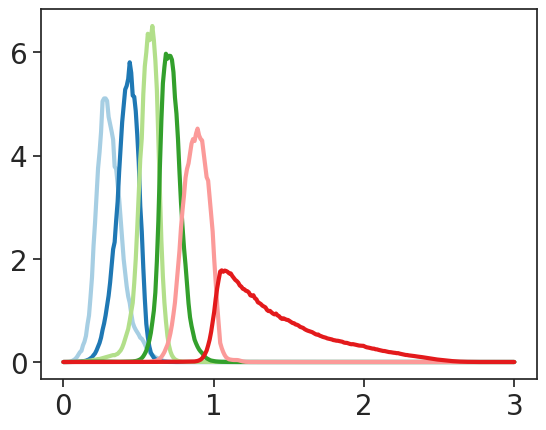

In [6]:
for i in range(6):
    plt.plot(myz, my_dndz_pos_norm[i,:])

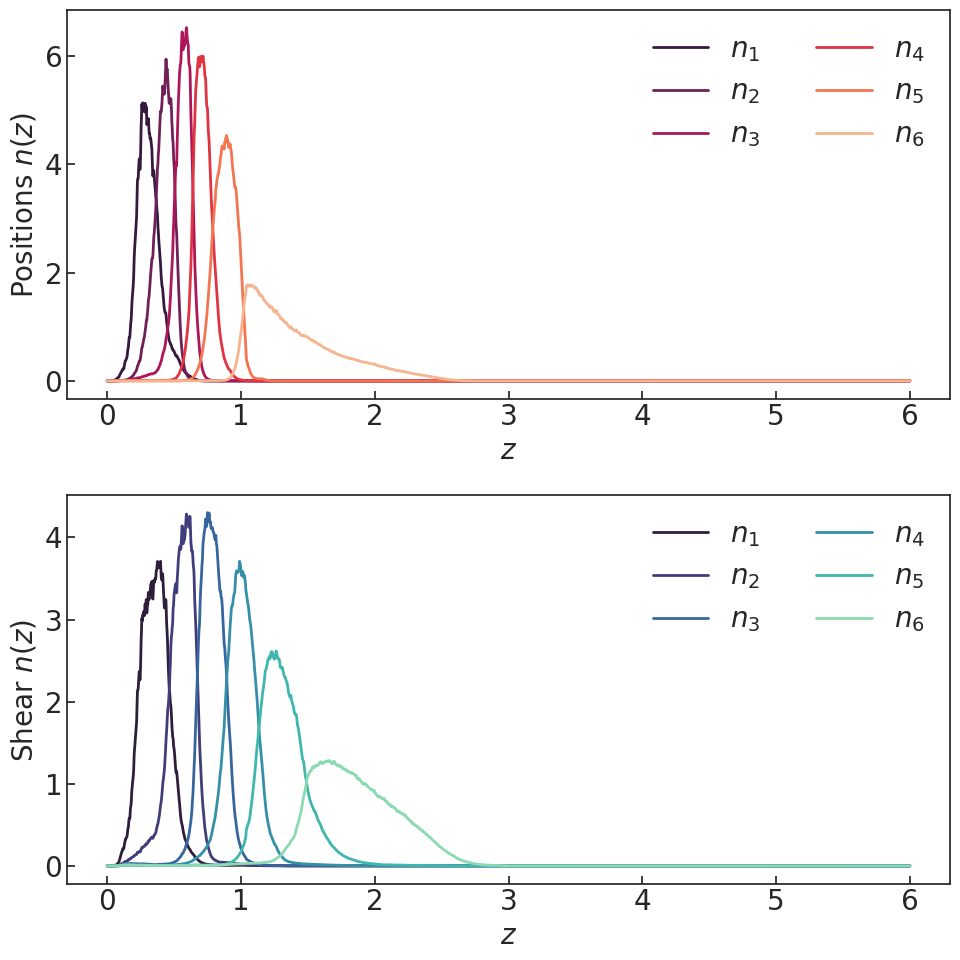

In [7]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos_norm[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she_norm[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

In [8]:
# Initialize Background cosmology
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
Omm = 0.3097
Omc = 0.26067408193677466
Omb = 0.04902591806322532
w = -1
wa = 0

background = JAXBackground(H0=H0,Omc=Omc,Omb=Omb, w=w, wa=wa, sigma8=sigma8, Omk = 0.0, ns = 0.96, gamma_MG = 0.545)
background = JAXBackground(67.74, 0.0486, 0.2589, 0.0, 0.8159, 0.9667, -1.0, 0.0, 0.55)

In [9]:
# Initialize Linear and NonLinearPerturbations
linear_pert = JAXLinearPerturbations(background)
nonlinear_pert = JAXNonLinearPerturbations(linear_pert)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


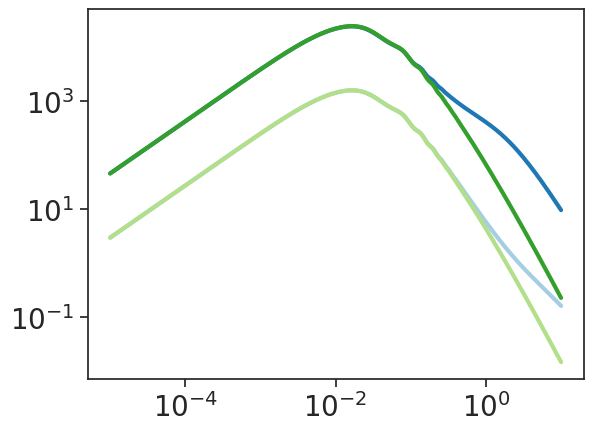

In [10]:
ks = np.logspace(-5,1,300)
plt.loglog(ks, nonlinear_pert.nonlinear_matter_power_spectrum(ks,4))
plt.loglog(ks, nonlinear_pert.nonlinear_matter_power_spectrum(ks,0))

plt.loglog(ks, linear_pert.linear_matter_power_spectrum(ks,4))
plt.loglog(ks, linear_pert.linear_matter_power_spectrum(ks,0))

In [11]:
tracer_she = photo.ShearTracer(nonlinear_pert,
                            dndz=my_dndz_pos_norm,
                            z = z_she,
                            intrinsic_aligment_model='zNLA',
                            nuisance_params={'param1': 1.0})

tracer_pos = photo.PositionsTracer(nonlinear_pert,
                            dndz=my_dndz_pos_norm,
                            z = myz,
                            magnification_bias_model = 'linear',
                            galaxy_bias_model= 'linear',
                            nuisance_params={'param1': 1.0})

In [12]:
tracer_pos.get_window_positions(myz).shape

(6, 300)

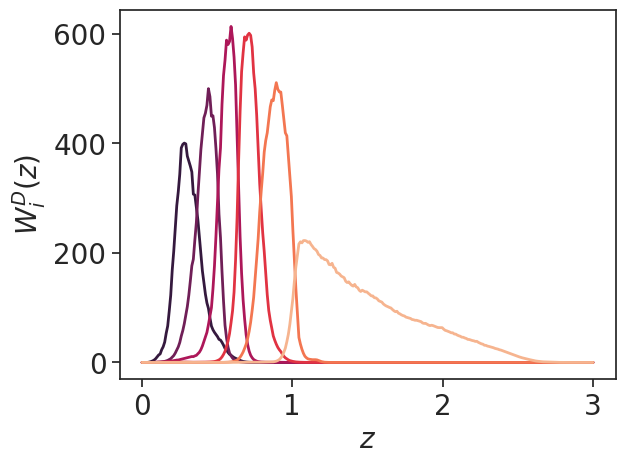

In [13]:
# Careful about the units of H(z)
# Note the D for positions (euclidlib internal map pointer :) )
for i in dndz_pos.keys():
    plt.plot(myz, tracer_pos.get_window_positions(myz)[i-1], linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i-1])
plt.xlabel(r'$z$')
plt.ylabel(r'$W^D_i(z)$');

In [14]:
twopt = AngularTwoPoint(tracer_pos, tracer_pos)

In [15]:
cl = twopt.get_Cl()

In [16]:
%timeit twopt.get_Cl()

874 ms ± 25.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


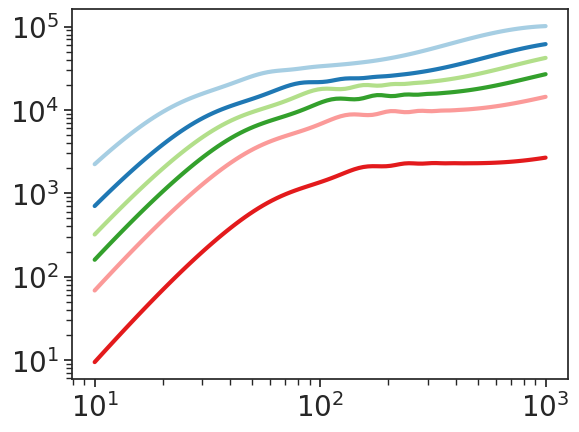

In [19]:
ell_range = np.logspace(1., 3., 100)
for i in range(6):
    plt.loglog(ell_range, ell_range*ell_range*cl[:,i,i])

In [ ]:
from scipy.interpolate import RectBivariateSpline
ks = np.logspace(-5, 2, 300)
zs = np.linspace(0., 3., 300)
ell_range = np.logspace(1., 3., 50)

#horrible Marco!
H = background.comoving_distance(myz)
chi = background.comoving_distance(myz)
ks_calc = np.outer(ell_range + 1, 1/chi)


chi2 = chi**2
Pk = nonlinear_pert.nonlinear_matter_power_spectrum(ks, zs)
pmm_logspline = RectBivariateSpline(zs, np.log10(ks), np.log10(Pk))
                                                #kx=self.angular_config.limber_spline_kx,
                                                #ky=self.angular_config.limber_spline_ky,
                                                #s=self.angular_config.limber_spline_s)
Pkl = np.zeros((50, 300))
k_lz = np.expand_dims((ell_range + 0.5), 1) / chi
for (z_idx, myz) in enumerate(zs):
    print(myz)
    Pkl[:, z_idx] = pmm_logspline(myz, np.log10(k_lz[:, z_idx]))

0.0
0.010033444816053512
0.020066889632107024
0.030100334448160536
0.04013377926421405
0.05016722408026756
0.06020066889632107
0.07023411371237459
0.0802675585284281
0.0903010033444816
0.10033444816053512
0.11036789297658864
0.12040133779264214
0.13043478260869565
0.14046822742474918
0.1505016722408027
0.1605351170568562
0.1705685618729097
0.1806020066889632
0.19063545150501673
0.20066889632107024
0.21070234113712374
0.22073578595317728
0.23076923076923078
0.2408026755852843
0.2508361204013378
0.2608695652173913
0.2709030100334448
0.28093645484949836
0.29096989966555187
0.3010033444816054
0.3110367892976589
0.3210702341137124
0.3311036789297659
0.3411371237458194
0.3511705685618729
0.3612040133779264
0.37123745819397996
0.38127090301003347
0.391304347826087
0.4013377926421405
0.411371237458194
0.4214046822742475
0.431438127090301
0.44147157190635455
0.45150501672240806
0.46153846153846156
0.47157190635451507
0.4816053511705686
0.4916387959866221
0.5016722408026756
0.5117056856187291
0.

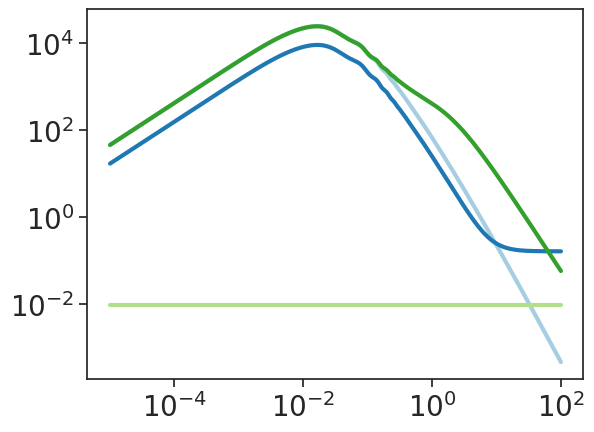

In [ ]:
plt.loglog(ks, Pk[:,0])
plt.loglog(ks, Pk[:,100])
plt.loglog(ks, Pk[:,290])
plt.loglog(ks, nonlinear_pert.nonlinear_matter_power_spectrum(ks, 0.))

In [ ]:
np.diff(np.log10(k_lz[:, 1]))

array([0.0389573 , 0.03911698, 0.03926373, 0.03939819, 0.03952125,
       0.03963414, 0.03973734, 0.03983182, 0.03991815, 0.0399971 ,
       0.04006924, 0.04013515, 0.04019535, 0.04025024, 0.04030037,
       0.04034614, 0.04038786, 0.04042598, 0.04046062, 0.0404923 ,
       0.04052116, 0.04054746, 0.04057144, 0.0405933 , 0.04061311,
       0.04063138, 0.04064783, 0.04066294, 0.04067662, 0.04068911,
       0.0407005 , 0.04071081, 0.04072034, 0.04072887, 0.04073679,
       0.04074383, 0.04075027, 0.04075623, 0.04076165, 0.04076654,
       0.04077101, 0.04077506, 0.04077876, 0.04078209, 0.04078519,
       0.04078805, 0.04079044, 0.04079282, 0.04079497], dtype=float32)

In [ ]:
pmm_logspline(1, 1)

array([[3.09096405]])

In [ ]:
Pk

Array([[4.5823349e+01, 4.5329990e+01, 4.4848934e+01, ..., 3.7490425e-03,
        3.2730680e-03, 2.8579743e-03],
       [4.8274582e+01, 4.7754833e+01, 4.7248047e+01, ..., 3.7490425e-03,
        3.2730680e-03, 2.8579743e-03],
       [5.0856930e+01, 5.0309376e+01, 4.9775482e+01, ..., 3.7490425e-03,
        3.2730680e-03, 2.8579743e-03],
       ...,
       [6.3773606e-04, 6.3143362e-04, 6.2547444e-04, ..., 3.7490425e-03,
        3.2730680e-03, 2.8579743e-03],
       [5.5071973e-04, 5.4535398e-04, 5.4030836e-04, ..., 3.7490425e-03,
        3.2730680e-03, 2.8579743e-03],
       [4.7560225e-04, 4.7104532e-04, 4.6678827e-04, ..., 3.7490425e-03,
        3.2730680e-03, 2.8579743e-03]], dtype=float32)

In [ ]:
back_instance = JAXBackground(67.74, 0.0486, 0.2589, 0.10, 0.8159, 0.9667, -1.0, 0.0, 0.55)
lin_pert_instance = JAXLinearPerturbations(back_instance)
nonlin_pert_instance = JAXNonLinearPerturbations(lin_pert_instance)

In [ ]:
Pk = nonlin_pert_instance.nonlinear_matter_power_spectrum(ks, zs)

In [ ]:
ks = np.logspace(-5, 2, 300)
zs = np.linspace(0., 3., 300)
nl = 500
ell_range = np.logspace(1., np.log10(3000), nl)

zs_calc = np.linspace(1e-3, 3., 300)#horrible Marco!
H = back_instance.hubble_parameter(zs_calc)
chi = back_instance.comoving_distance(zs_calc)
ks_calc = np.outer(ell_range + 1, 1/chi)


chi2 = chi**2
Pk = jax.vmap(nonlin_pert_instance.nonlinear_matter_power_spectrum, in_axes = (0, None))(ks,zs)
#nonlin_pert_instance.nonlinear_matter_power_spectrum(ks, zs)
pmm_logspline = RectBivariateSpline(np.log10(ks), zs, np.log10(Pk), kx = 3, ky = 3, s = 0)
                                                #kx=self.angular_config.limber_spline_kx,
                                                #ky=self.angular_config.limber_spline_ky,
                                                #s=self.angular_config.limber_spline_s)
Pkl = np.zeros((nl, 300))
k_lz = np.expand_dims((ell_range + 0.5), 1) / chi
for (z_idx, myz) in enumerate(zs_calc):
    Pkl[:, z_idx] = 10**pmm_logspline(np.log10(k_lz[:, z_idx]), myz)[:,0]

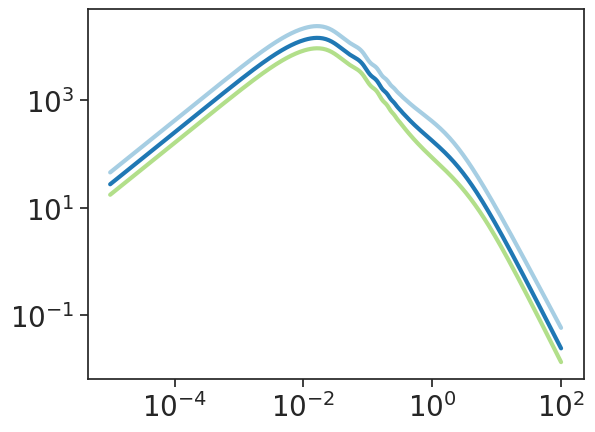

In [ ]:
plt.loglog(ks, Pk[:, 0])
plt.loglog(ks, Pk[:, 50])
plt.loglog(ks, Pk[:, 100])

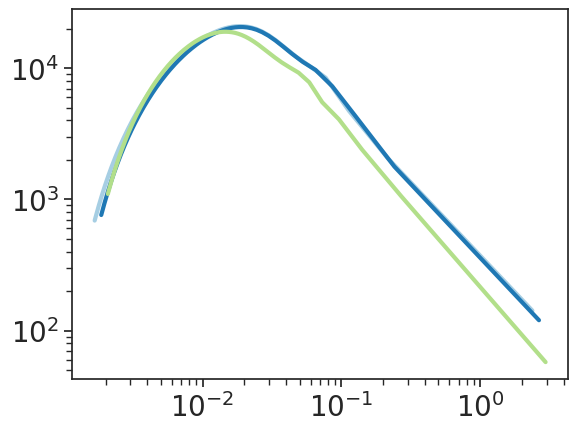

In [ ]:
plt.loglog(k_lz[0,:], Pkl[0, :])
plt.loglog(k_lz[10,:], Pkl[10, :])
plt.loglog(k_lz[20,:], Pkl[49, :])

In [ ]:
WT1 = tracer_pos.get_window_positions(zs_calc)
WT2 = tracer_pos.get_window_positions(zs_calc)
result = np.einsum('iz,jz,lz,z,z->lij', WT1, WT2, Pkl, 1/H, 1/chi2)

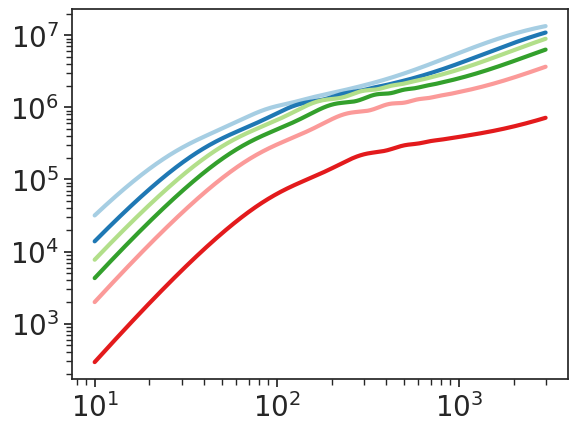

In [ ]:
for i in range(6):
    plt.loglog(ell_range, ell_range*ell_range*result[:,i,i])

In [ ]:
tracer_pos.perturbations.nonlinear_matter_power_spectrum